In [1]:
import pandas as pd
import zipfile
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

In [2]:
dir = Path("/home/py/groundwater/data/gown/raw/active")

In [3]:
banff = pd.read_csv('/home/py/groundwater/data/bow_valley/stream/Stage.Working@05BB001.20110101_corrected.csv', skiprows=14, usecols=[1, 2], parse_dates=[0], index_col=0).squeeze()
banff = banff+1376.388
banff = banff.resample('h').mean()

In [4]:
wells = ['0764', '0760', '0759', '0364'] 

In [5]:
stream = pd.read_csv('/home/py/groundwater/data/bow_valley/stream/bow_river_interpolated.csv', parse_dates=[0], index_col=0)

In [6]:
well_dfs = {}

for well in wells:
    with zipfile.ZipFile(dir / f'{well}.zip', 'r') as z:
        well_dfs[well] = pd.read_csv(z.open("tsvalues.csv"), skiprows=9, sep=';', usecols=[0,2], parse_dates=[0], index_col=0).squeeze()
        well_dfs[well].index = well_dfs[well].index.tz_localize(None)

In [7]:
def plot_same(range):
    for well, df in well_dfs.items():
        fig, ax = plt.subplots(figsize=(11, 4))

        ax.plot(stream[well].loc[range[0]:range[1]].index, stream[well].loc[range[0]:range[1]], "tab:blue", label="Bow stage")
        ax.plot(df.loc[range[0]:range[1]].index, df.loc[range[0]:range[1]], "tab:red", label=f"{well} level")

        ax.set_ylabel("Elevation (m)")
        ax.set_title(f"({range[0]} to {range[1]}) Bow River near {well} vs GOWN {well}")
        ax.legend()

        fig.autofmt_xdate()
        fig.tight_layout()

In [8]:
def plot_twin(range):
    for well, df in well_dfs.items():
        fig, ax = plt.subplots(figsize=(11, 4))

        ax.plot(stream[well].loc[range[0]:range[1]].index, stream[well].loc[range[0]:range[1]], "tab:blue")
        ax.set_ylabel("Bow stage at Banff (m)", color="tab:blue")

        a2 = ax.twinx()
        a2.plot(df.loc[range[0]:range[1]].index, df.loc[range[0]:range[1]], "tab:red")
        a2.set_ylabel(f"{well} level (masl)", color="tab:red")

        ax.set_title(f"({range[0]} to {range[1]}) Bow River near {well} vs GOWN {well}")

        fig.autofmt_xdate()
        fig.tight_layout()

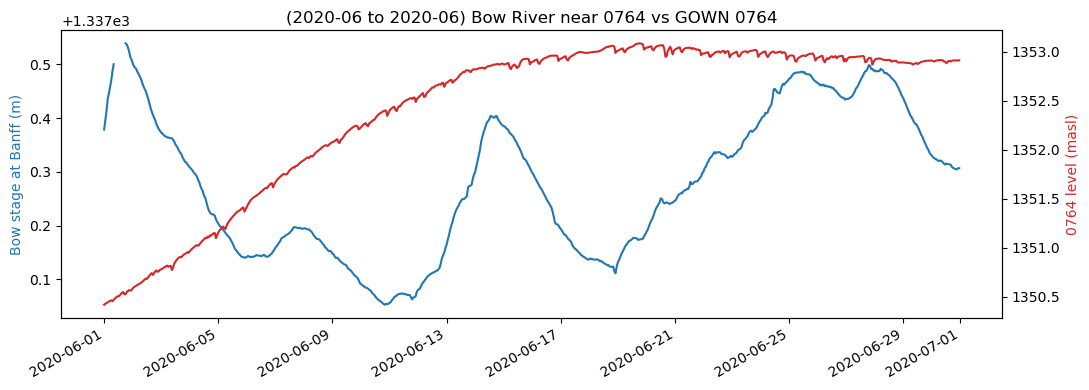

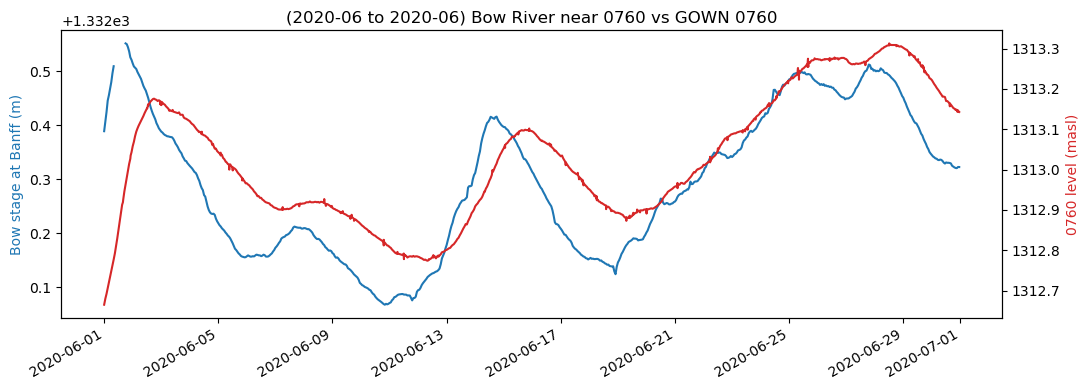

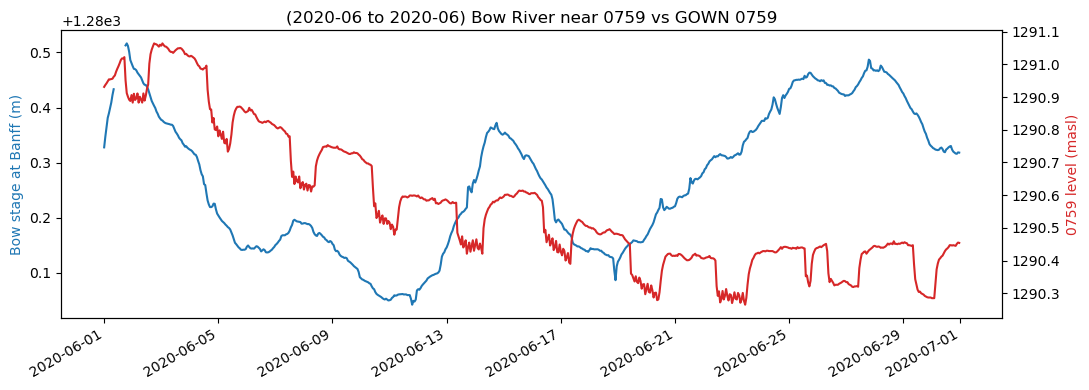

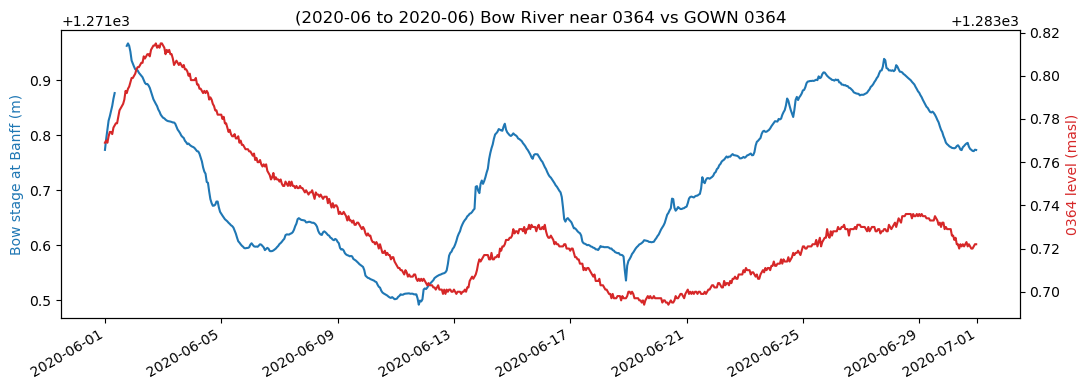

In [9]:
plot_twin(("2020-06", "2020-06"))

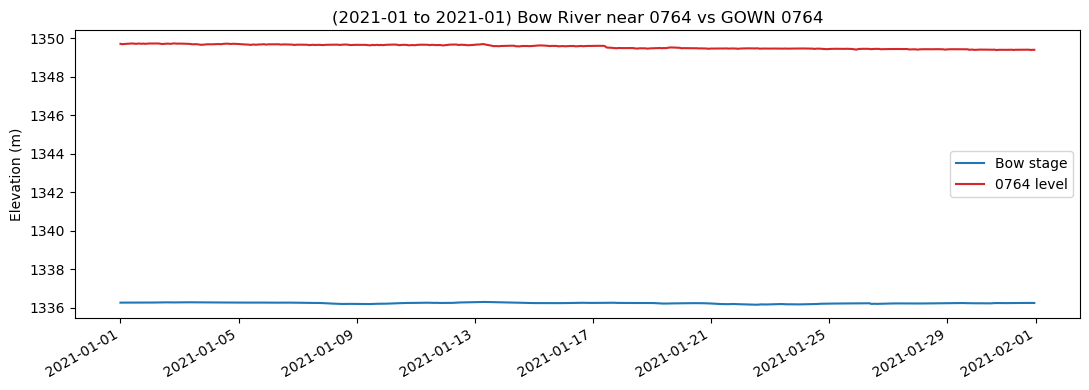

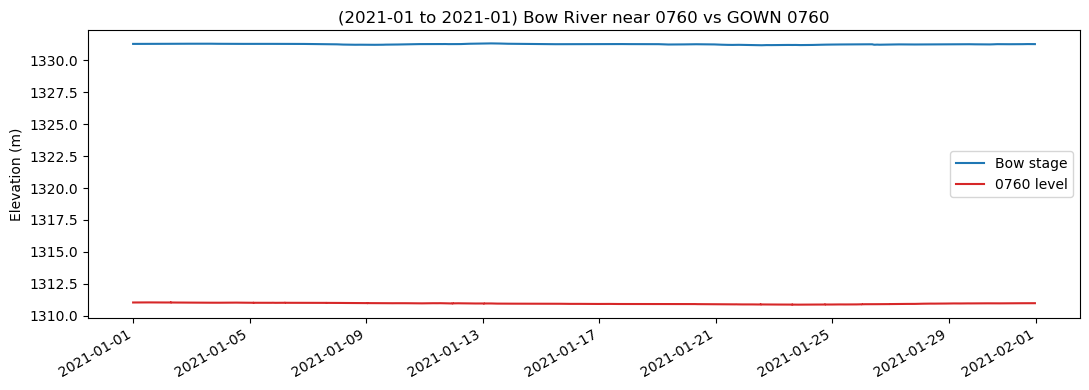

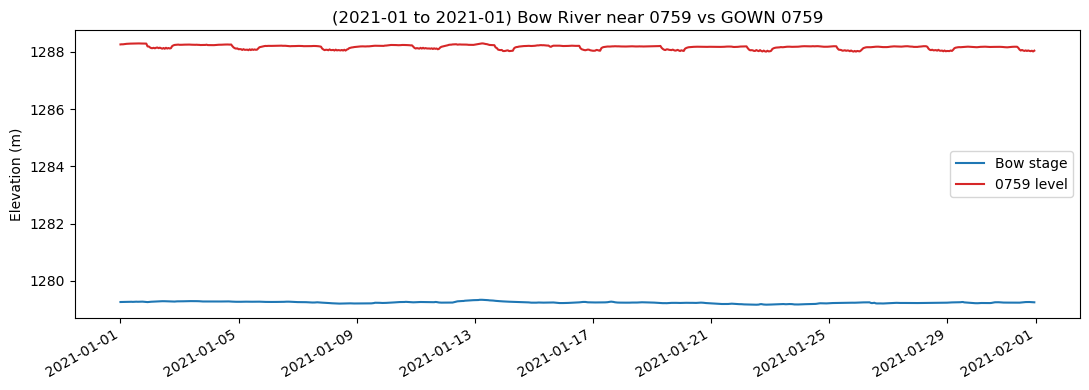

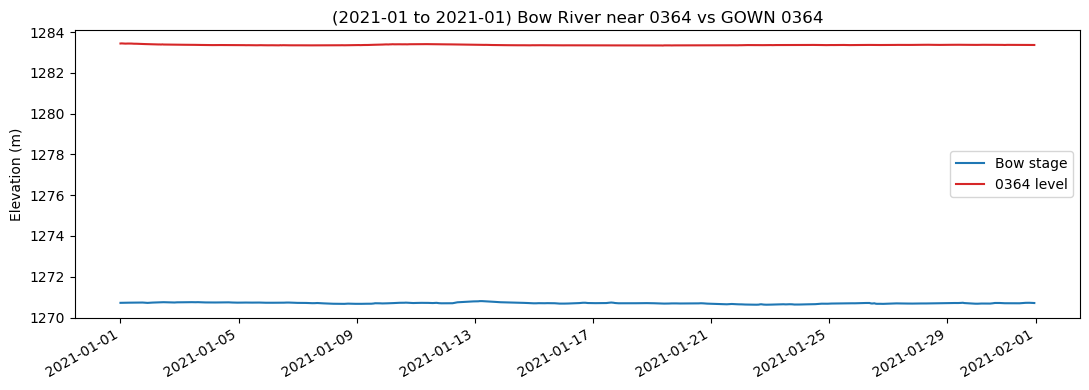

In [10]:
plot_same(("2021-01", "2021-01"))

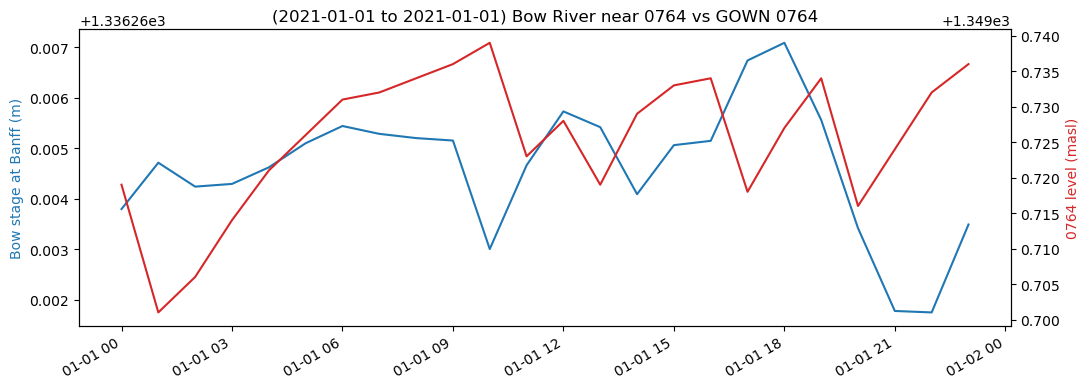

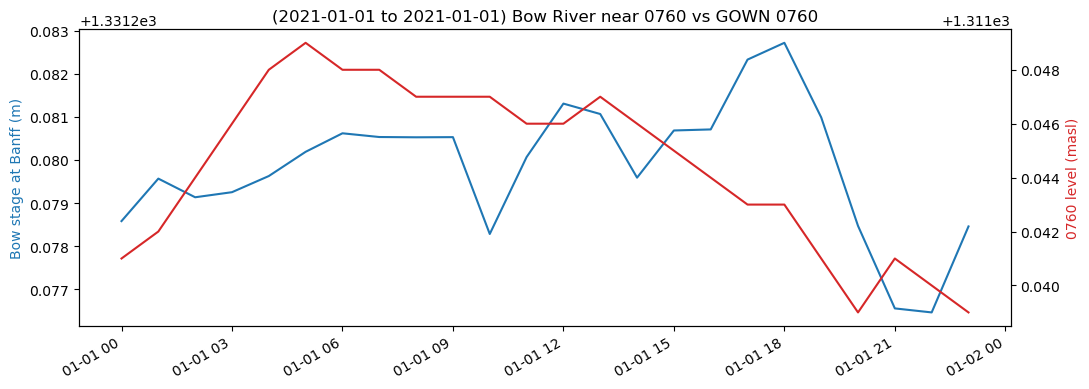

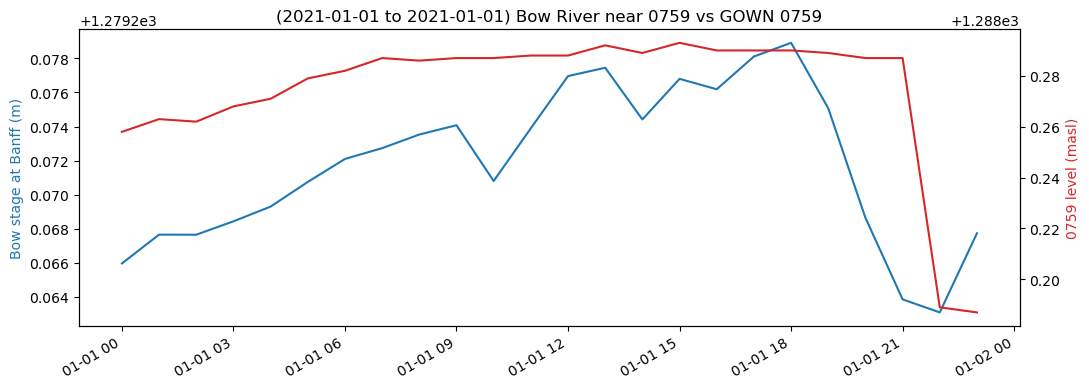

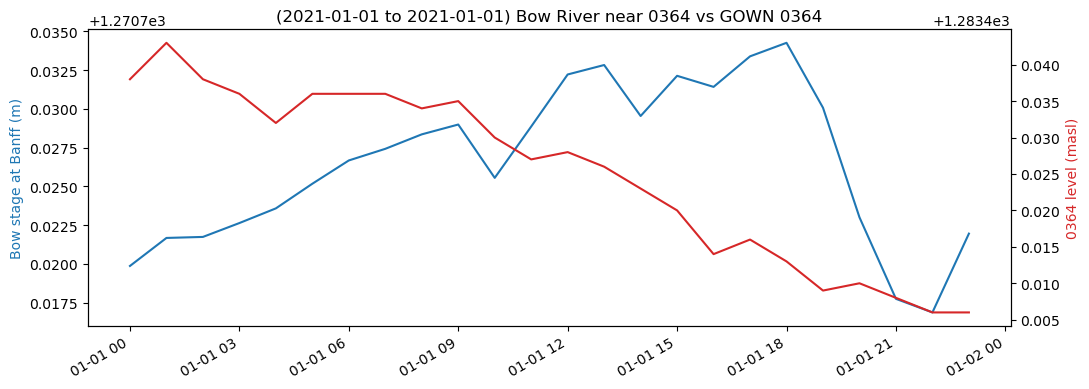

In [11]:
range = ("2021-01-01", "2021-01-01")
plot_twin(range)

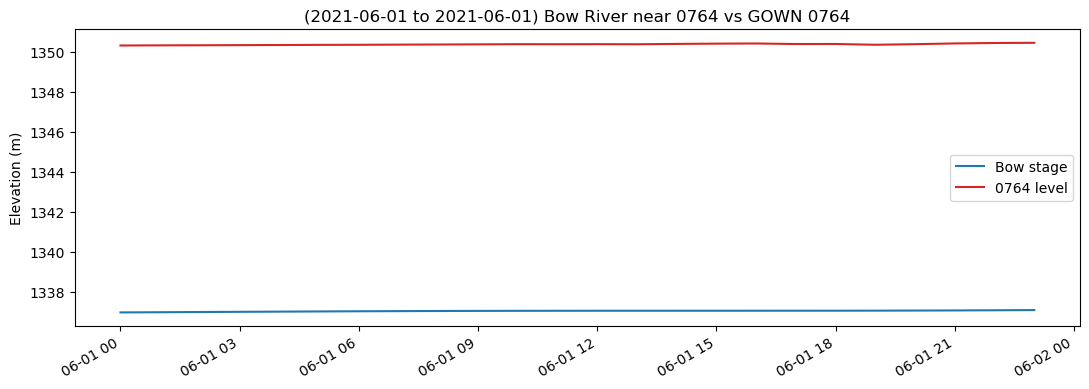

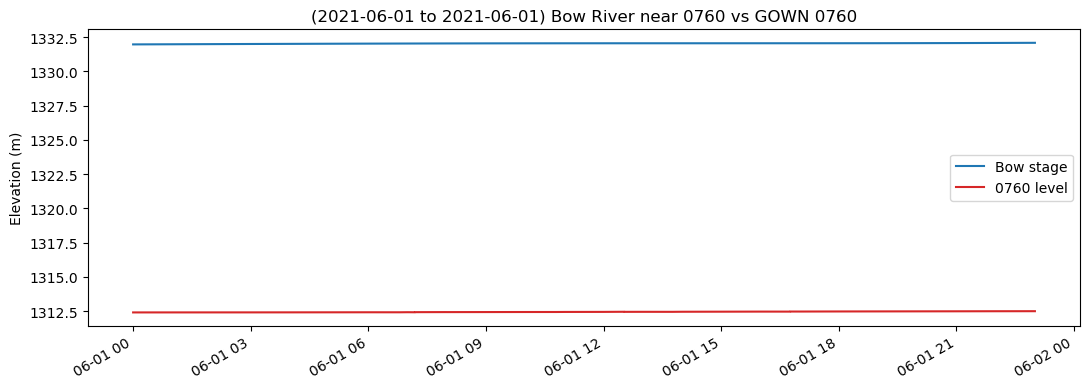

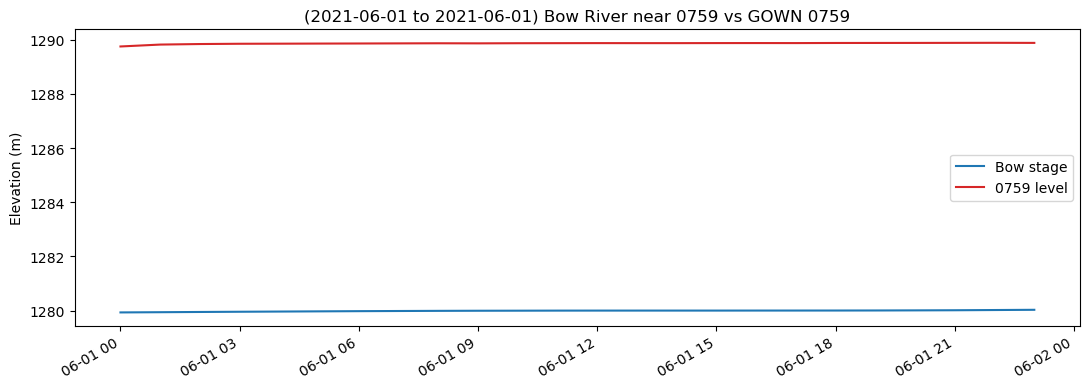

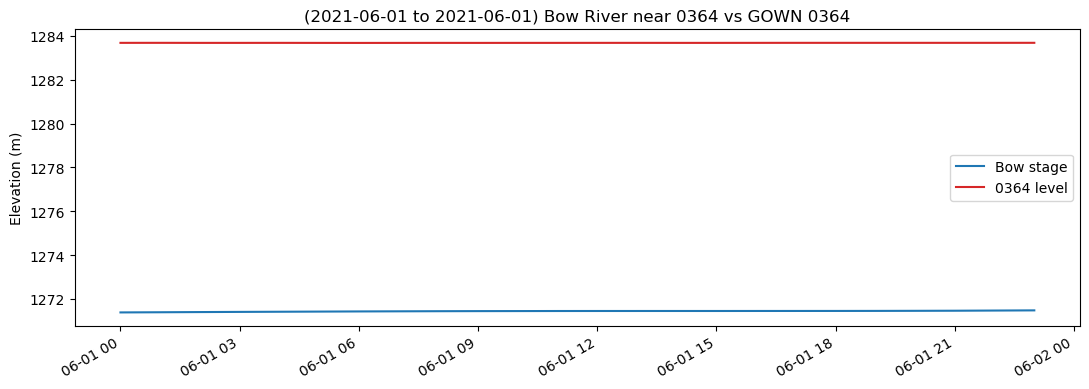

In [12]:
range = ("2021-06-01", "2021-06-01")
plot_same(range)

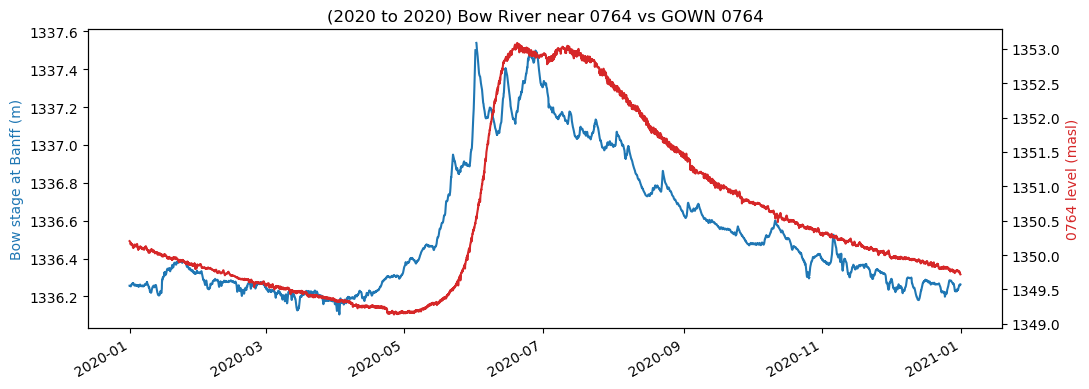

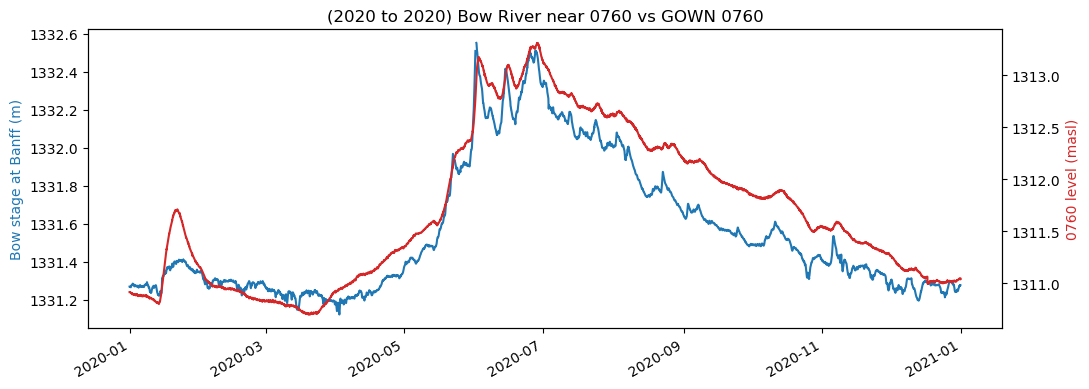

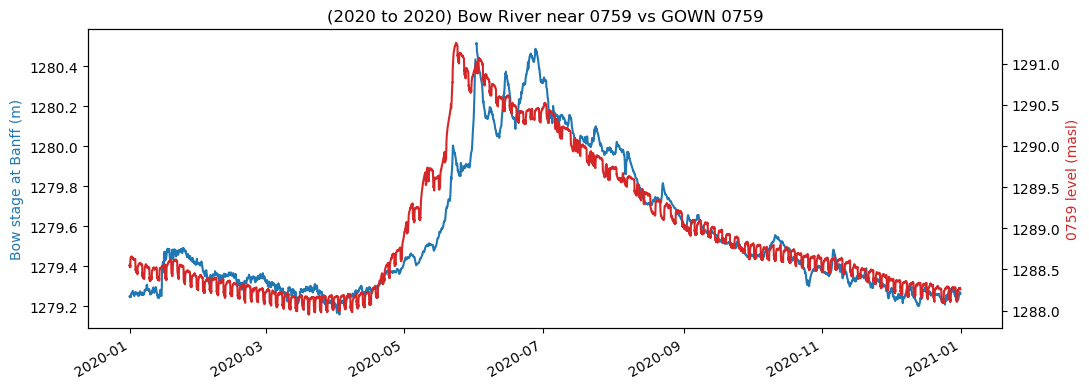

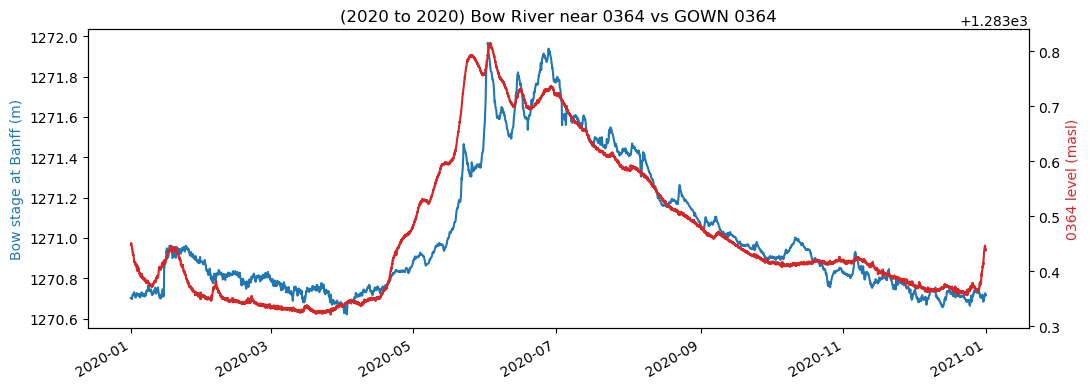

In [13]:
range = ("2020", "2020")
plot_twin(range)

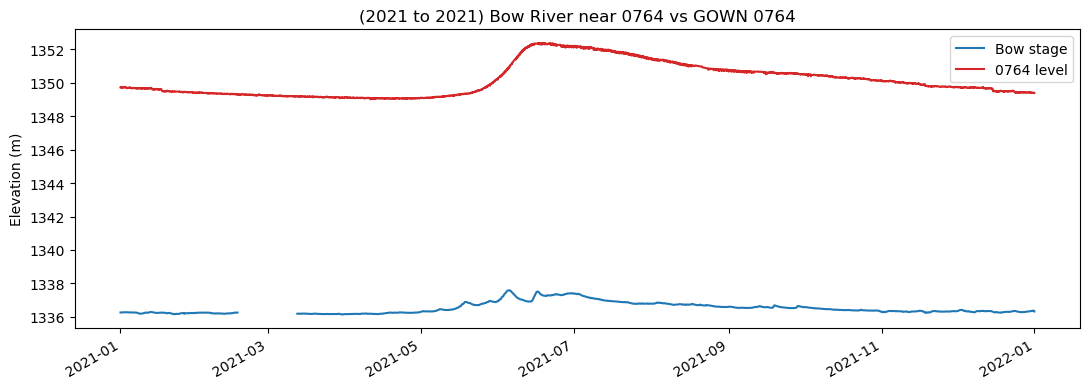

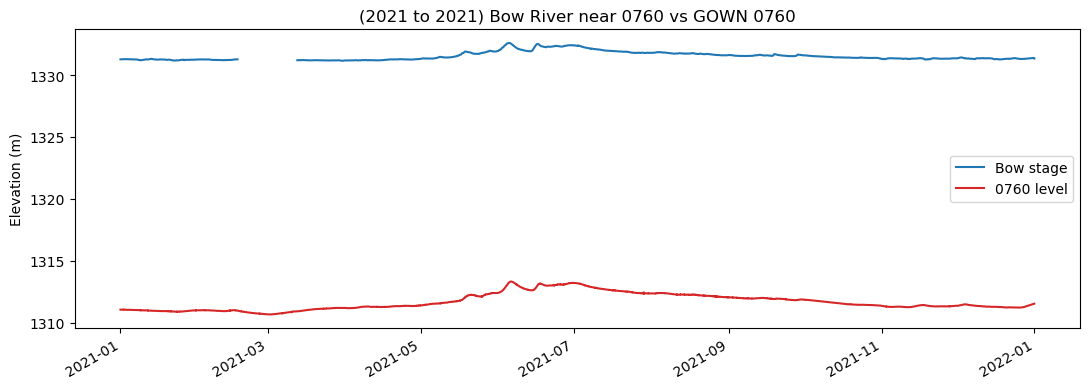

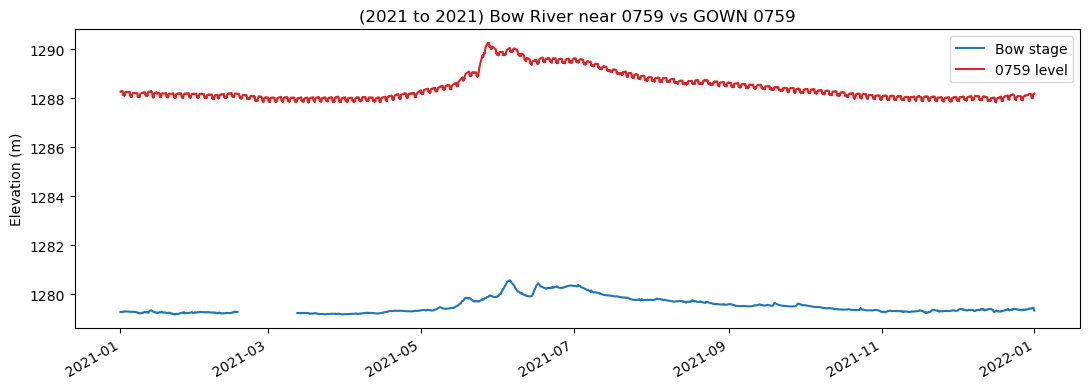

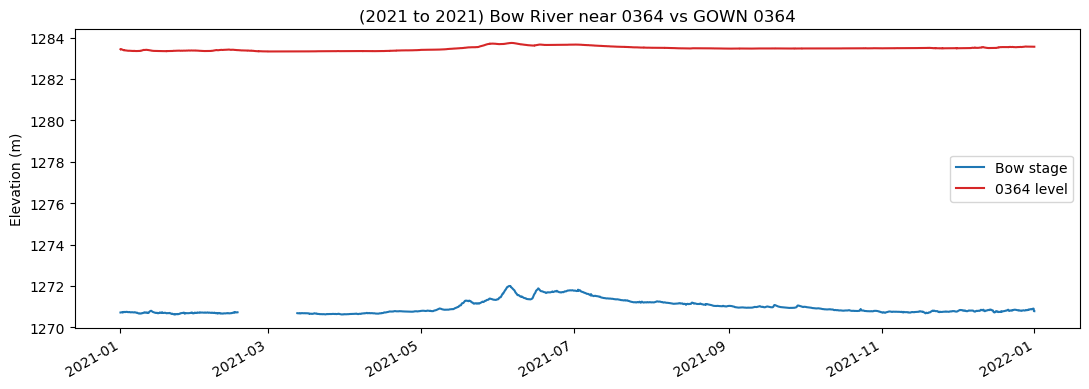

In [14]:
range = ("2021", "2021")
plot_same(range)

<Axes: xlabel='#Timestamp'>

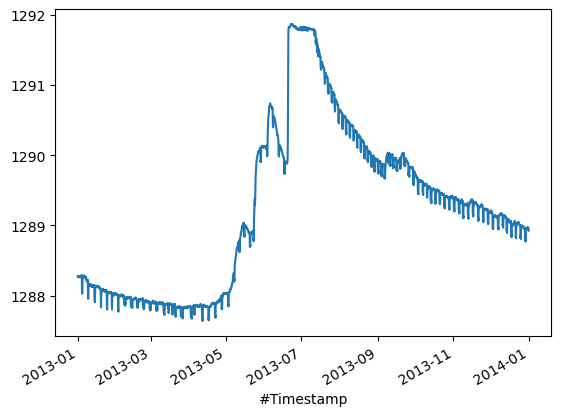

In [28]:
well_dfs['0759'].loc['2013'].plot()

<Axes: xlabel='#Timestamp'>

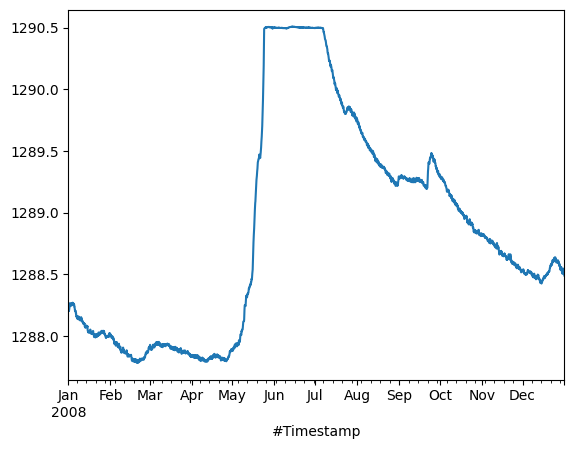

In [27]:
well_dfs['0759'].loc['2008'].plot()